# Data preparation for Llama
Stage 2 & 3

In [152]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## A Overview

In [153]:
from pathlib import Path
import pandas as pd

# plotting the distribution of confidence scores by class for failed predictions
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import configuration

from src import hf_utils, setup
from src.models import bert

In [154]:
datasets_path = Path("..") / "data"/"splitted" / "stage_2"
strategy = "isolated" # "crossed" or "isolated"
df_predictions = pd.read_csv(datasets_path / strategy / "llama_pre_bert_sets_with_predictions.csv")
df_predictions.shape

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_22396/3662462052.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_predictions = pd.read_csv(datasets_path / strategy / "llama_pre_bert_sets_with_predictions.csv")


(2933542, 7)

In [155]:
df_failed_predictions = df_predictions[df_predictions["informative"] != df_predictions["predicted"]]
print(df_failed_predictions.shape)
df_failed_predictions.head()

(36555, 7)


,uid,tweet_text,informative,humanitarian_label,subset,predicted,confidence
3,178535,"If I have a specialization, what can i do to f...",True,not_humanitarian,disaster,0,0.692796
8,229637,RT @HighvTweet: Empire State Buildings lit up ...,False,not_humanitarian,disaster,1,0.898826
26,217232,http://t.co/6ezlEVGnCI Congrats to PNoy &amp; ...,False,not_related_or_irrelevant,disaster,1,0.855646
31,162598,[In a statement](http://somalimidnimo.com/sala...,True,not_humanitarian,disaster,0,0.958680
34,4960,RT @julia_zba: By Timothy Allen - #nepal http:...,False,not_related_or_irrelevant,disaster,1,0.617487


/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_22396/3143798802.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Informative")


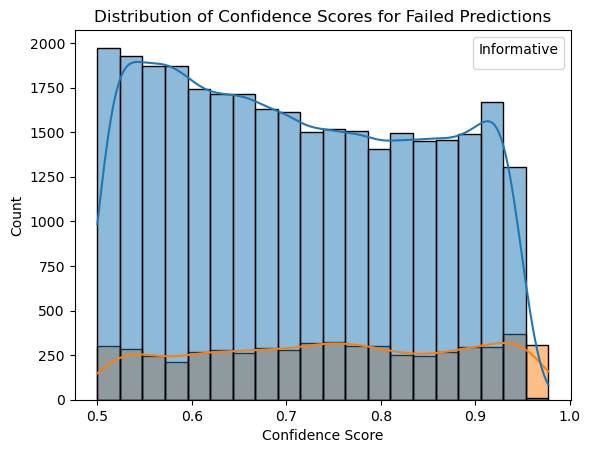

In [156]:

sns.histplot(data=df_failed_predictions, x="confidence", hue="informative", bins=20, kde=True)
plt.title("Distribution of Confidence Scores for Failed Predictions")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.legend(title="Informative")
plt.show()


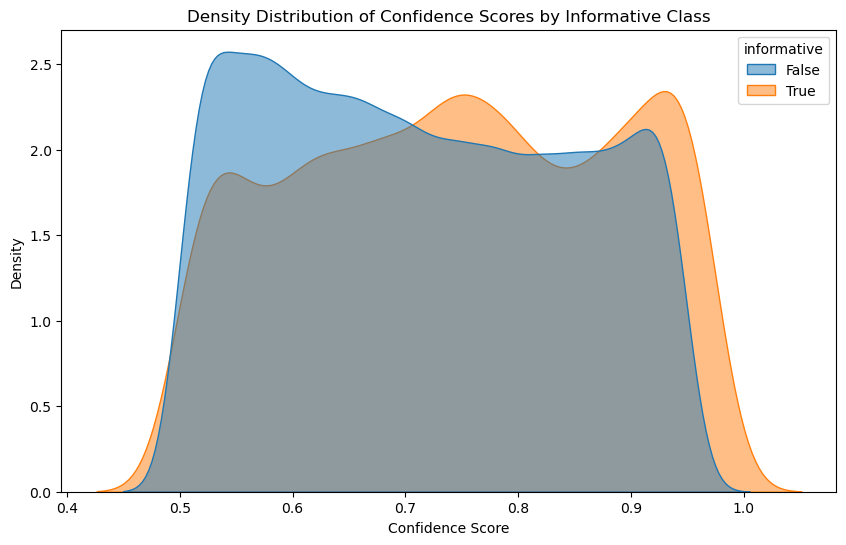

In [157]:
plt.figure(figsize=(10, 6))
# common_norm=False ensures each class's density is scaled independently
sns.kdeplot(
    data=df_failed_predictions, 
    x="confidence", 
    hue="informative", 
    fill=True, 
    common_norm=False, 
    alpha=0.5
)
plt.title("Density Distribution of Confidence Scores by Informative Class")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.show()

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_22396/1872297451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


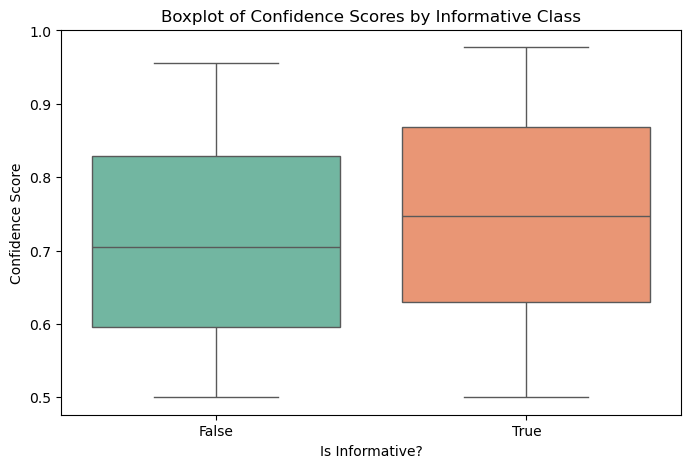

In [158]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_failed_predictions, 
    x="informative", 
    y="confidence",
    palette="Set2"
)
plt.title("Boxplot of Confidence Scores by Informative Class")
plt.xlabel("Is Informative?")
plt.ylabel("Confidence Score")
plt.show()

## B. Re-distribute for cross strategy

In [184]:
df_false_negatives = df_failed_predictions[df_failed_predictions["informative"]]
df_false_positives = df_failed_predictions[~df_failed_predictions["informative"]]

times = 2
n = len(df_false_negatives) * times

df_false_positives = df_false_positives.sample(n=n, random_state=setup.RANDOM_SEED)

df = pd.concat([df_false_negatives, df_false_positives])
df.shape


(17097, 7)

In [185]:
df.shape

(17097, 7)

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_22396/3788694560.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Informative")


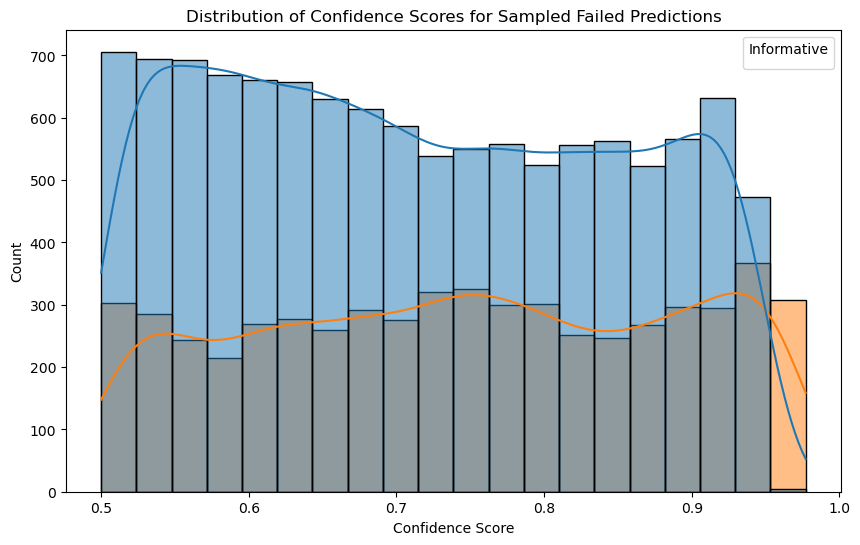

In [186]:
# plot sampled_df to check the distribution of confidence scores
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="confidence", bins=20, hue="informative", kde=True)
plt.title("Distribution of Confidence Scores for Sampled Failed Predictions")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.legend(title="Informative")
plt.show()

## C. Spliting

In [187]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=setup.RANDOM_SEED, stratify=df["informative"])

df_test, df_validation = train_test_split(df_test, test_size=0.5, random_state=setup.RANDOM_SEED, stratify=df_test["informative"])
print(f"Train set shape: {df_train.shape}")
print(f"Validation set shape: {df_validation.shape}")
print(f"Test set shape: {df_test.shape}")

Train set shape: (13677, 7)
Validation set shape: (1710, 7)
Test set shape: (1710, 7)


In [188]:
save_path = datasets_path / strategy / f"{times}_times"
save_path.mkdir(parents=True, exist_ok=True)
df_train.to_csv(save_path / "df_train.csv", index=False)
df_validation.to_csv(save_path / "df_validation.csv", index=False)
df_test.to_csv(save_path / "df_test.csv", index=False)